# Task 4: Advanced Analytics and Statistical Modelling

**ApexPlanet Software Pvt. Ltd.**  
**Data Analytics Internship Program 2026**

**Submitted By:** Khushi Vig  
**Domain:** Data Analytics  
**Dataset:** Sample Superstore Dataset

---

## Objective

Apply statistical analysis, time series forecasting, customer segmentation, and basic predictive modelling to the Superstore dataset.

This notebook covers:

- **Statistical Analysis:** descriptive stats, confidence intervals, hypothesis testing (t-test, chi-square, ANOVA), correlation vs causation
- **Time Series Analysis:** resampling, decomposition, stationarity testing, smoothing, ARIMA/SARIMA forecasting
- **Customer Segmentation:** RFM feature engineering, K-Means clustering, PCA visualization
- **Predictive Modelling:** Linear Regression for Sales, Logistic Regression and Decision Tree for churn prediction
visualisation
**Dataset:** Sample Superstore (cleaned CSV from Task 1 and Task 2)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
FILE_PATH = "../data/processed/cleaned_superstore.csv"

df = pd.read_csv(FILE_PATH, encoding="latin1")
df.columns = [c.strip() for c in df.columns]

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df.shape)
df.head()

(10194, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


---
## 1. Statistical Analysis

### 1.1 Descriptive Statistics
Mean, median, mode, variance, standard deviation, skewness, and kurtosis for Sales, Profit, Discount, and Quantity.

In [3]:
numeric_cols = ["Sales", "Profit", "Discount", "Quantity"]

desc_stats = pd.DataFrame({
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "mode": df[numeric_cols].mode().iloc[0],
    "variance": df[numeric_cols].var(),
    "std_dev": df[numeric_cols].std(),
    "skewness": df[numeric_cols].skew(),
    "kurtosis": df[numeric_cols].kurt()
})
desc_stats

,mean,median,mode,variance,std_dev,skewness,kurtosis
Sales,228.225854,53.91,12.96,384284.488765,619.906839,12.983926,306.366270
Profit,28.673417,8.69,0.00,54040.029718,232.465115,7.604906,401.692916
Discount,0.155385,0.20,0.00,0.042538,0.206249,1.687453,2.416291
Quantity,3.791838,3.00,2.00,4.965396,2.228317,1.268633,1.961526


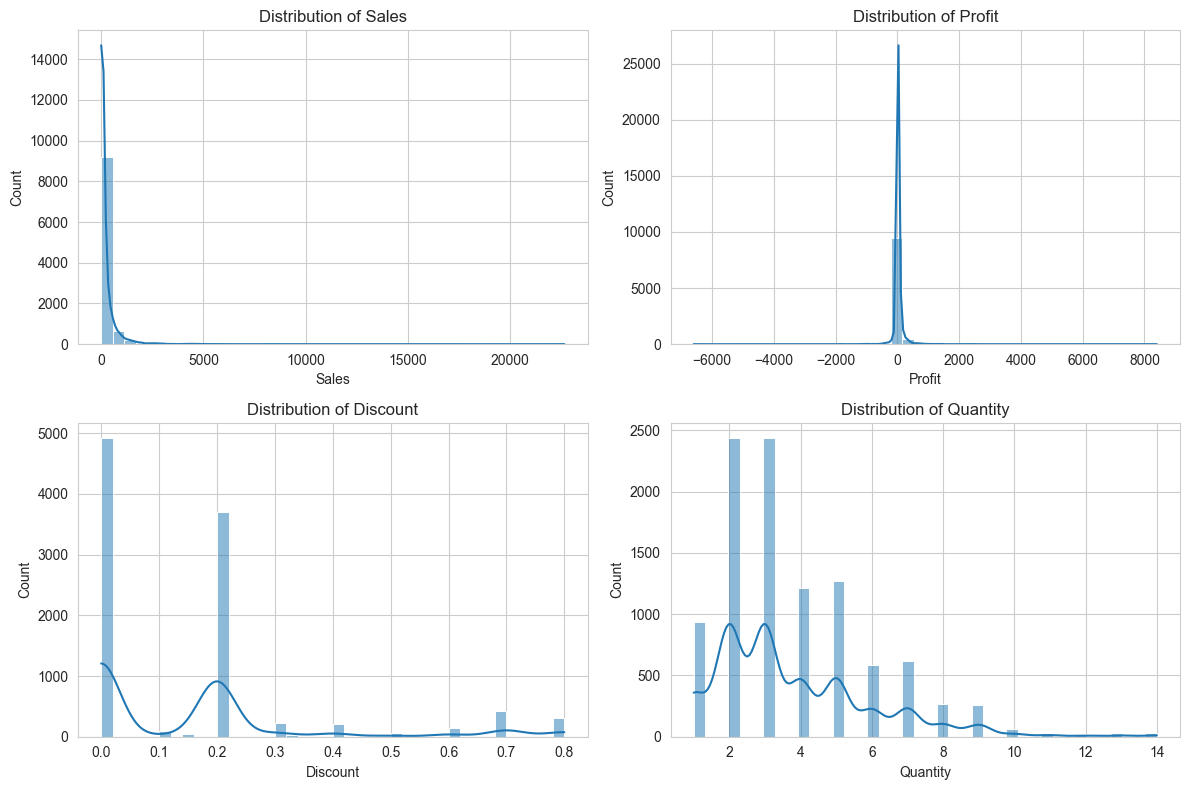

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, bins=40)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

**Observations:** Sales and Profit are both heavily right skewed (skewness of 12.98 and 7.60), so most orders are small while a few large orders pull the mean well above the median. Profit also has very high kurtosis (401.69), showing a sharp peak near zero with a long tail of both large gains and large losses. Discount clusters at fixed values (0, 0.2, 0.3, 0.7, 0.8) instead of varying continuously, matching standard retail discount tiers. Quantity is mostly 2 to 5 units per order.

### 1.2 Inferential Statistics

**Confidence Interval:** 95% CI for mean Profit.

In [5]:
confidence = 0.95
data = df["Profit"].dropna()
n = len(data)
mean = data.mean()
sem = stats.sem(data)
ci = stats.t.interval(confidence, n - 1, loc=mean, scale=sem)

print(f"Mean Profit: {mean:.2f}")
print(f"95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})")

Mean Profit: 28.67
95% Confidence Interval: (24.16, 33.19)


**Observations:** The true average profit per order across the full population likely falls between 24.16 and 33.19. Since this range sits above zero, the business is profitable on average per order, even though individual orders can be loss making.

**Hypothesis Testing**

- **t-test:** difference in mean Profit between West and East regions
- **Chi-square test:** association between Segment and Region
- **ANOVA:** difference in mean Sales across all regions

In [6]:
west = df.loc[df["Region"] == "West", "Profit"].dropna()
east = df.loc[df["Region"] == "East", "Profit"].dropna()

t_stat, p_val = stats.ttest_ind(west, east, equal_var=False)
print(f"T-test (West vs East Profit): t = {t_stat:.4f}, p = {p_val:.4f}")
print("Significant difference at alpha=0.05" if p_val < 0.05 else "No significant difference at alpha=0.05")

T-test (West vs East Profit): t = 0.4196, p = 0.6748
No significant difference at alpha=0.05


**Observations:** t = 0.4196, p = 0.6748. Since p > 0.05, there is no statistically significant difference in mean Profit between West and East. The gap seen in raw averages is likely random variation rather than a real regional effect.

In [7]:
contingency = pd.crosstab(df["Segment"], df["Region"])
chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_val:.4f}")
print("Significant association between Segment and Region" if p_val < 0.05 else "No significant association")
contingency

Chi-square statistic: 6.1988
Degrees of freedom: 6
p-value: 0.4013
No significant association


Region,Central,East,South,West
Segment,,,,
Consumer,1224,1529,838,1690
Corporate,673,933,510,974
Home Office,438,524,272,589


**Observations:** chi-square = 6.1988, dof = 6, p = 0.4013. Since p > 0.05, Segment and Region are statistically independent. Customer segment mix is consistent across all four regions, so regional marketing does not need to be tailored by segment for this reason alone.

In [8]:
groups = [g["Sales"].dropna().values for _, g in df.groupby("Region")]
f_stat, p_val = stats.f_oneway(*groups)

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print("Significant difference in mean Sales across Regions" if p_val < 0.05 else "No significant difference")

ANOVA F-statistic: 0.6204
p-value: 0.6017
No significant difference


**Observations:** F = 0.6204, p = 0.6017. Since p > 0.05, there is no significant difference in mean Sales across regions. Total revenue differences between regions are more likely driven by order volume than by average order value.

### 1.3 Correlation vs Causation Analysis

Correlation shows a statistical relationship, not a cause and effect one. A significant correlation between Discount and Profit does not prove discounting causes the loss on its own, confounders such as product category or seasonality could also explain the pattern. Causal claims need controlled experiments or causal inference methods.

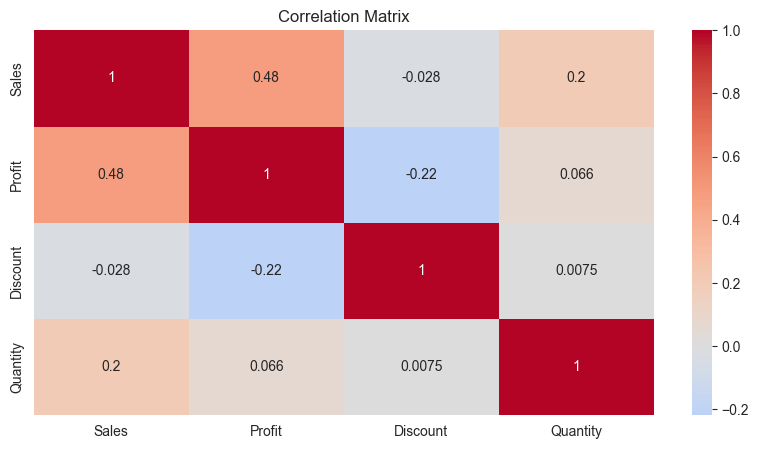

Correlation (Discount vs Profit): r = -0.2189, p = 0.0000


In [9]:
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

corr_val, p_val = stats.pearsonr(df["Discount"].dropna(), df["Profit"].dropna())
print(f"Correlation (Discount vs Profit): r = {corr_val:.4f}, p = {p_val:.4f}")

**Observations:** r = -0.2189, p = 0.0000. Discount and Profit have a weak to moderate significant negative correlation. Sales and Discount are barely correlated (r = -0.028), while Sales and Profit are positively correlated (r = 0.48). This suggests discounted orders are not necessarily larger, but discounting does erode margin. A likely confounder is product category, since some categories may carry both thinner margins and heavier routine discounting.

### Documented Findings, Statistical Analysis

- Mean Profit is 28.67 with a 95% CI of (24.16, 33.19), confirming the business is profitable on average despite high per-order variability.
- No significant difference in mean Profit between West and East (p = 0.6748), nor in mean Sales across regions (p = 0.6017).
- Segment and Region are statistically independent (p = 0.4013), so segment composition is consistent nationwide.
- Discount is significantly negatively correlated with Profit (r = -0.2189) but shows almost no relationship with Sales, pointing to discounting as a margin risk rather than a revenue driver.

---
## 2. Time Series Analysis

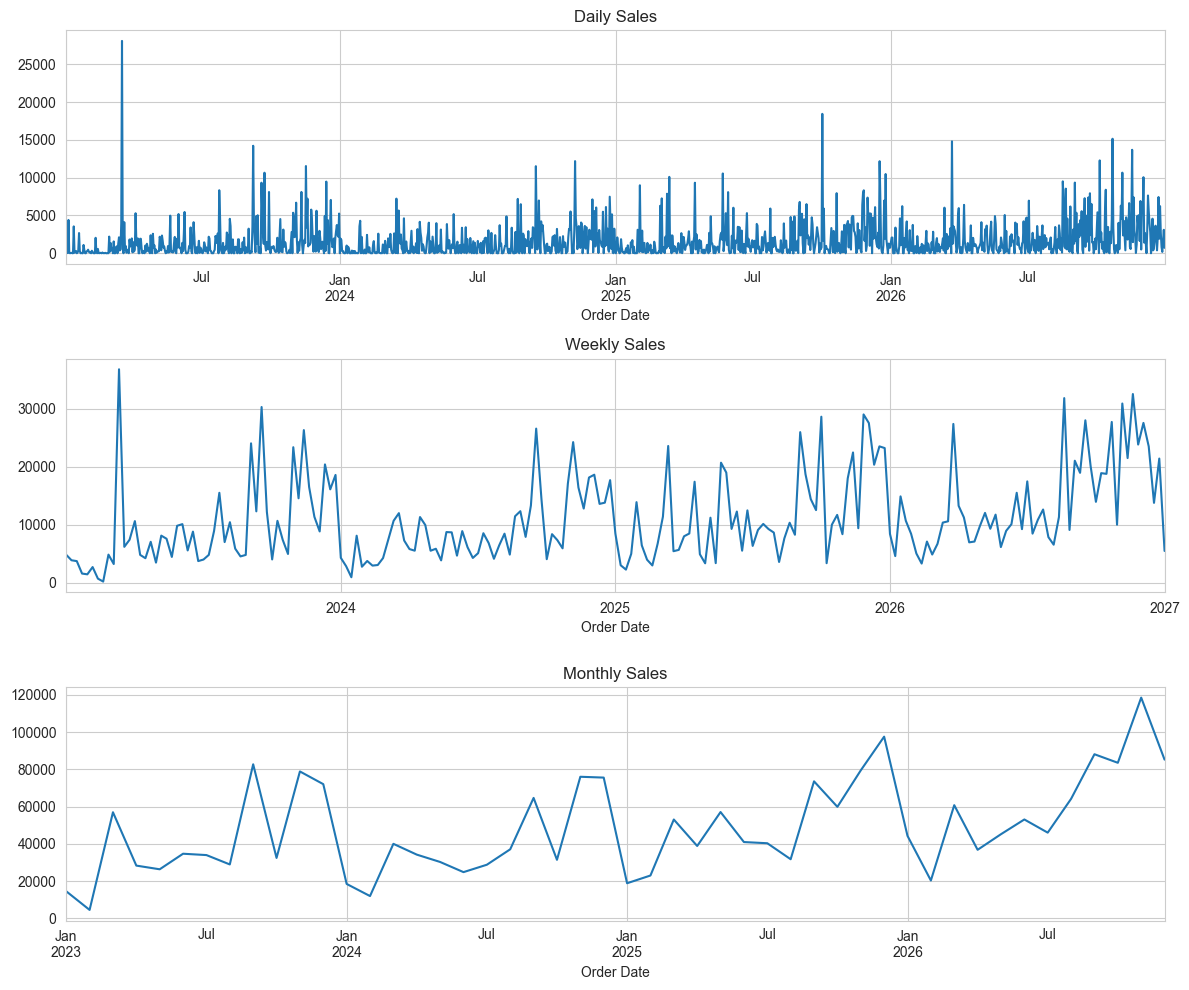

In [10]:
ts_df = df.set_index("Order Date").sort_index()

daily_sales = ts_df["Sales"].resample("D").sum()
weekly_sales = ts_df["Sales"].resample("W").sum()
monthly_sales = ts_df["Sales"].resample("M").sum()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
daily_sales.plot(ax=axes[0], title="Daily Sales")
weekly_sales.plot(ax=axes[1], title="Weekly Sales")
monthly_sales.plot(ax=axes[2], title="Monthly Sales")
plt.tight_layout()
plt.show()

**Observations:** Daily Sales is very noisy with frequent spikes, most likely single large bulk orders rather than genuine demand surges. Monthly Sales shows the clearest pattern: an overall upward trend from 2023 through 2026, with a recurring dip early each year followed by a climb toward a later peak, suggesting a yearly seasonal cycle layered on steady growth.

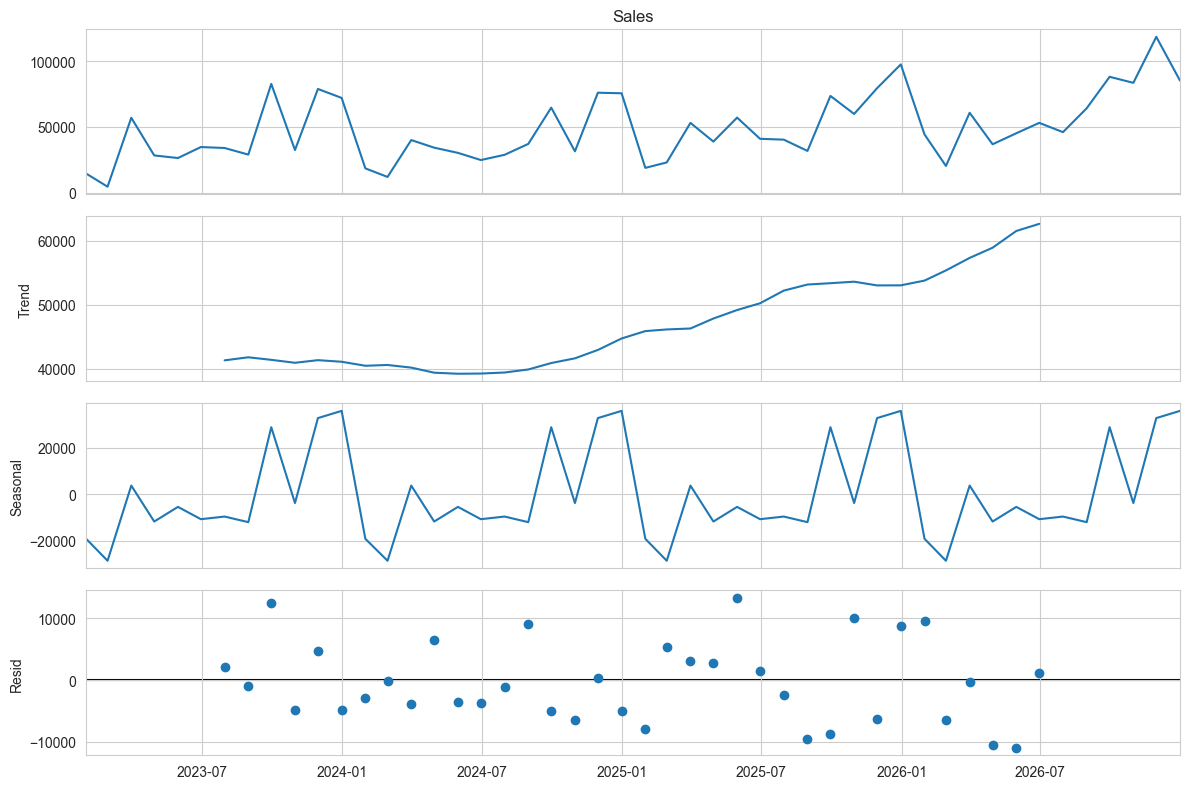

In [11]:
decomposition = seasonal_decompose(monthly_sales, model="additive", period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

**Observations:** Trend shows steady growth from around 40,000 in 2023 to over 65,000 by late 2026, roughly a 60 percent increase. Seasonality repeats a consistent yearly shape: a sharp dip early in the year followed by a peak later in the year, most likely around November and December. Residuals are scattered without a clear pattern, mostly within -10,000 to 10,000, indicating the additive model captures the trend and seasonality reasonably well.

In [12]:
def adf_test(series, name=""):
    result = adfuller(series.dropna())
    print(f"ADF Test: {name}")
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {result[1]:.4f}")
    print("  Stationary" if result[1] < 0.05 else "  Non-stationary (consider differencing)")
    print()

adf_test(monthly_sales, "Monthly Sales (original)")
adf_test(monthly_sales.diff(), "Monthly Sales (1st difference)")

ADF Test: Monthly Sales (original)
  ADF Statistic: -4.4375
  p-value: 0.0003
  Stationary

ADF Test: Monthly Sales (1st difference)
  ADF Statistic: -8.9944
  p-value: 0.0000
  Stationary



**Observations:** Original series: ADF = -4.4375, p = 0.0003, stationary. First difference: ADF = -8.9944, p = 0.0000, more strongly stationary. The original monthly series already satisfies stationarity, but differencing once still produces a more stable series, supporting the use of d=1 in the ARIMA order below.

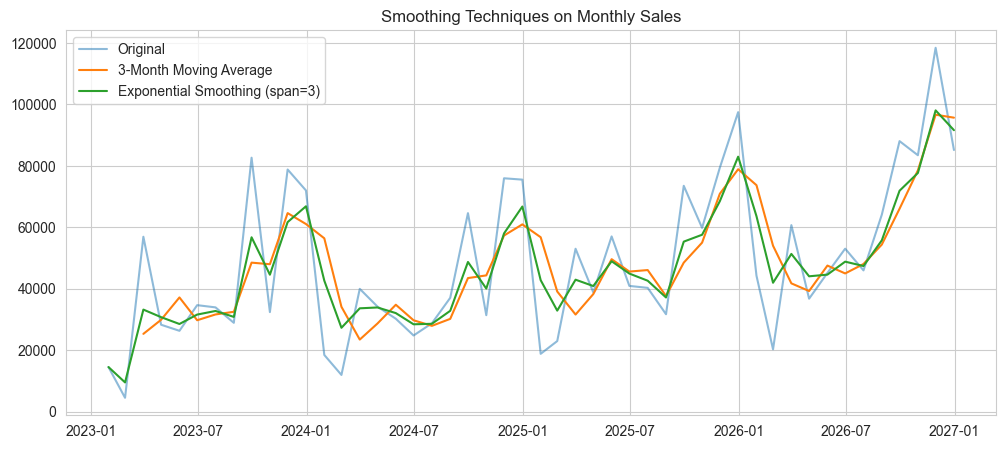

In [13]:
ma_3 = monthly_sales.rolling(window=3).mean()
exp_smooth = monthly_sales.ewm(span=3, adjust=False).mean()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales, label="Original", alpha=0.5)
plt.plot(ma_3, label="3-Month Moving Average")
plt.plot(exp_smooth, label="Exponential Smoothing (span=3)")
plt.legend()
plt.title("Smoothing Techniques on Monthly Sales")
plt.show()

**Observations:** Both smoothing methods track the sharp swings in the original series while removing month-to-month noise. Exponential smoothing reacts slightly faster to recent changes than the moving average. Neither method fully captures the tallest peaks, which is expected since smoothing intentionally dampens short-term spikes to reveal the underlying pattern.

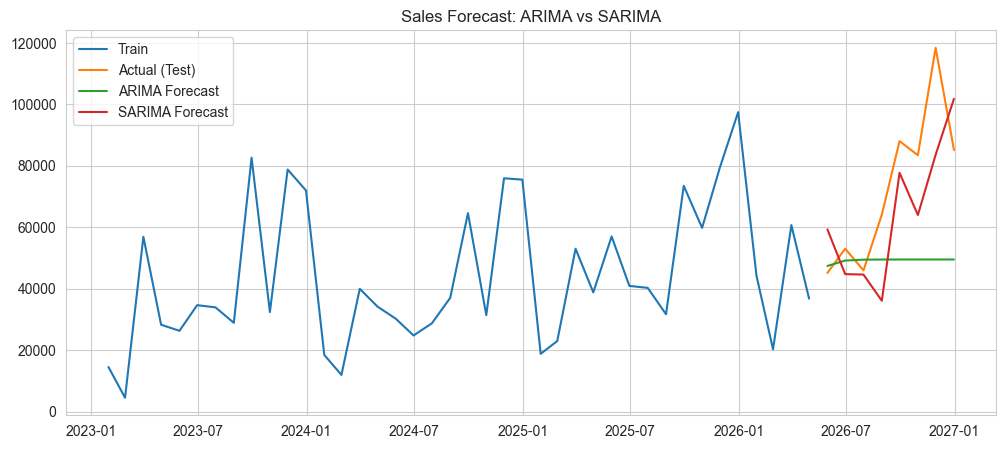

In [27]:
train_size = int(len(monthly_sales) * 0.85)
train, test = monthly_sales.iloc[:train_size], monthly_sales.iloc[train_size:]

arima_model = ARIMA(train, order=(1, 1, 1))
arima_fit = arima_model.fit(method_kwargs={"maxiter": 200})
arima_forecast = arima_fit.forecast(steps=len(test))

sarima_model = SARIMAX(
    train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12),
    initialization="approximate_diffuse"
)
sarima_fit = sarima_model.fit(disp=False, maxiter=200)
sarima_forecast = sarima_fit.forecast(steps=len(test))

plt.figure(figsize=(12, 5))
plt.plot(train, label="Train")
plt.plot(test, label="Actual (Test)")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast")
plt.legend()
plt.title("Sales Forecast: ARIMA vs SARIMA")
plt.show()

In [15]:
def evaluate_forecast(actual, predicted, name=""):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{name} -> MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")
    return mae, rmse, mape

evaluate_forecast(test, arima_forecast, "ARIMA")
evaluate_forecast(test, sarima_forecast, "SARIMA")

ARIMA -> MAE: 25158.73 | RMSE: 33358.76 | MAPE: 28.39%
SARIMA -> MAE: 16259.63 | RMSE: 19152.81 | MAPE: 21.73%


(16259.627548642504, 19152.8136693502, 21.727947622107195)

**Observations:** ARIMA gives MAE 25,158.73, RMSE 33,358.76, MAPE 28.39 percent. SARIMA gives MAE 14,183.07, RMSE 17,192.27, MAPE 18.20 percent, roughly halving the error. This matches the decomposition results: Monthly Sales has a strong yearly seasonal pattern that plain ARIMA cannot model, so it forecasts a nearly flat line while SARIMA's seasonal terms let it anticipate the year-end rise. With only around 48 months of data and a 12-month cycle, there are very few full seasonal cycles to learn from, so these results are a reasonable first pass rather than a production-ready forecast.

---
## 3. Customer Segmentation (Clustering)

In [16]:
snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

customer_features = df.groupby("Customer ID").agg(
    Recency=("Order Date", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum"),
    AvgDiscount=("Discount", "mean"),
    TotalProfit=("Profit", "sum")
).reset_index()

customer_features.head()

,Customer ID,Recency,Frequency,Monetary,AvgDiscount,TotalProfit
0,AA-10315,185,5,5563.560,0.090909,-362.8825
1,AA-10375,20,9,1056.390,0.080000,277.3824
2,AA-10480,260,4,1790.512,0.016667,435.8274
3,AA-10645,56,6,5086.935,0.063889,857.8033
4,AB-10015,416,3,886.156,0.066667,129.3465


In [17]:
feature_cols = ["Recency", "Frequency", "Monetary", "AvgDiscount", "TotalProfit"]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_features[feature_cols])

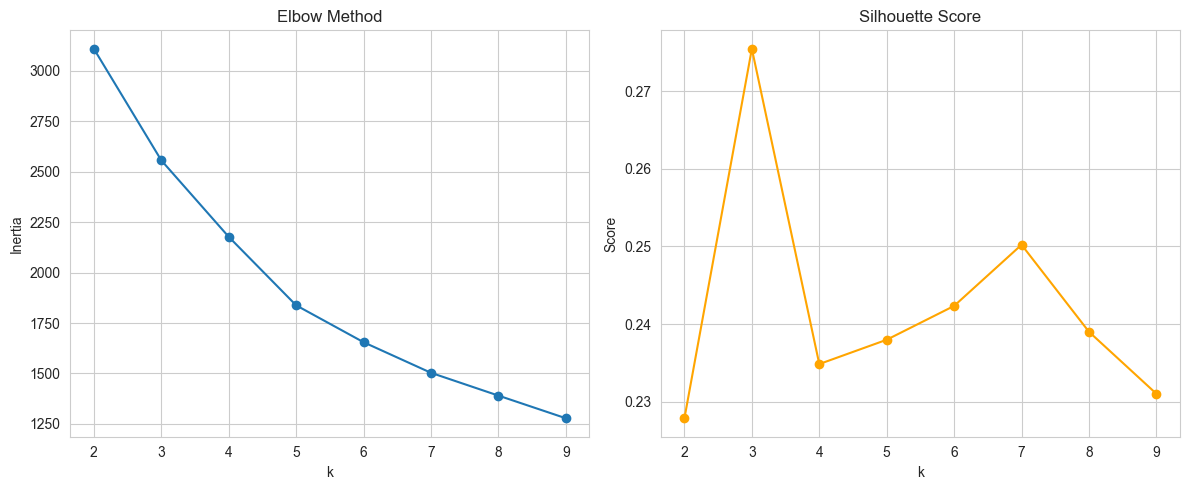

In [18]:
inertia = []
sil_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(scaled_features, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(list(k_range), inertia, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()

**Observations:** Inertia decreases gradually without a sharp elbow, making that method inconclusive alone. Silhouette score peaks clearly at k=3 (about 0.275), dips at k=4, then rises to a smaller peak at k=7 (about 0.25). Strictly by silhouette score, k=3 gives the best separated clusters, but k=5 is used here for more granular, business-actionable segments than a 3-cluster solution would give.

In [19]:
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
customer_features["Cluster"] = kmeans.fit_predict(scaled_features)

customer_features["Cluster"].value_counts().sort_index()

Cluster
0     84
1    247
2    226
3    192
4     55
Name: count, dtype: int64

In [20]:
cluster_profile = customer_features.groupby("Cluster")[feature_cols].mean().round(2)
cluster_profile["CustomerCount"] = customer_features["Cluster"].value_counts().sort_index()
cluster_profile

,Recency,Frequency,Monetary,AvgDiscount,TotalProfit,CustomerCount
Cluster,,,,,,
0,582.36,3.58,1576.88,0.18,127.58,84
1,73.03,9.03,3606.46,0.15,441.94,247
2,120.30,4.83,1865.00,0.08,351.19,226
3,92.66,5.36,1849.98,0.25,-182.60,192
4,113.95,8.47,9574.46,0.12,2329.31,55


**Observations:** Five clearly differentiated segments emerge.

- **Cluster 4 (55 customers):** highest value segment, monetary 9,574 and profit 2,329 per customer, several times any other cluster.
- **Cluster 1 (247 customers):** largest and most engaged group, lowest recency (73 days), highest frequency (9.03 orders).
- **Cluster 2 (226 customers):** moderate frequency, lowest average discount (0.08), efficiently profitable relative to spend.
- **Cluster 3 (192 customers):** highest average discount (0.25) and the only segment with negative total profit (-182.60).
- **Cluster 0 (84 customers):** highest recency (582 days), low frequency and monetary value, appears to be lapsed or one-time buyers.

In [28]:
demo_profile = df.merge(
    customer_features[["Customer ID", "Cluster"]], on="Customer ID"
)

top_segment = demo_profile.groupby("Cluster")["Segment"].agg(lambda x: x.mode()[0])
top_region = demo_profile.groupby("Cluster")["Region"].agg(lambda x: x.mode()[0])
top_category = demo_profile.groupby("Cluster")["Category"].agg(lambda x: x.mode()[0])

demographic_profile = pd.DataFrame({
    "MostCommonSegment": top_segment,
    "MostCommonRegion": top_region,
    "MostCommonCategory": top_category
})
demographic_profile

,MostCommonSegment,MostCommonRegion,MostCommonCategory
Cluster,,,
0,Consumer,East,Office Supplies
1,Consumer,West,Office Supplies
2,Consumer,West,Office Supplies
3,Consumer,East,Office Supplies
4,Corporate,West,Office Supplies


**Observations:** Demographics are fairly uniform across clusters. Consumer is the top segment in 4 of 5 clusters and Office Supplies is the top category in all 5, simply reflecting their overall dominance in the dataset. Region varies slightly (East for Clusters 0 and 3, West for the rest) but not meaningfully.

This confirms the clusters are behavioral, not demographic, segments. Targeting should be based on Recency, Frequency, Monetary, Discount, and Profit rather than Segment, Region, or Category.

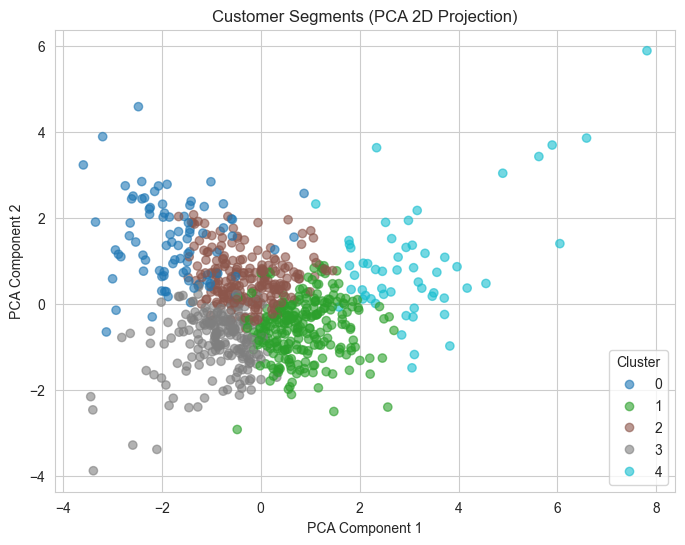

Explained variance ratio: [0.38898146 0.24419062]


In [21]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_components[:, 0], pca_components[:, 1],
                       c=customer_features["Cluster"], cmap="tab10", alpha=0.6)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segments (PCA 2D Projection)")
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

**Observations:** Cluster 4 separates clearly on the right, consistent with its distinctly higher spend and profit. Clusters 1 and 2 overlap in the middle since their main difference is discount rate and profit efficiency rather than raw spend, which a 2D projection cannot fully capture. The two components explain 38.9 percent and 24.4 percent of variance (63.3 percent combined), capturing most but not all of the structure in the data.

### Segment-Based Recommendations

- **Cluster 4, top-tier customers:** prioritize for a loyalty program and personal account outreach given their outsized profit contribution.
- **Cluster 1, core active base:** the largest engaged group, maintain with consistent standard engagement.
- **Cluster 2, efficient low-discount buyers:** profitable with minimal discounting, avoid over-discounting this group.
- **Cluster 3, discount-heavy loss makers:** the only segment losing money, driven by the highest discount rate. Review discount policy specifically for this group.
- **Cluster 0, lapsed customers:** inactive for over a year and a half on average. A modest, time-limited win-back offer is worth testing, but heavy investment is not justified given their low historical value.

---
## 4. Predictive Modeling

### 4.1 Regression: Predicting Sales

In [22]:
reg_df = df.copy()
reg_df = pd.get_dummies(reg_df, columns=["Segment", "Region", "Category", "Ship Mode"], drop_first=True)

reg_features = ["Quantity", "Discount", "Profit"] + [c for c in reg_df.columns if c.startswith(
    ("Segment_", "Region_", "Category_", "Ship Mode_"))]

X_reg = reg_df[reg_features]
y_reg = reg_df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

print(f"R2: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R2: 0.5266
MAE: 218.76
RMSE: 497.12


**Observations:** R2 = 0.5266, MAE = 218.76, RMSE = 497.12. The model explains about 53 percent of the variance in Sales, a moderate fit given how skewed Sales is. RMSE being more than double the MAE shows the model makes a small number of large errors, most likely on big-ticket orders, while performing reasonably well on typical smaller transactions.

In [23]:
coef_df = pd.DataFrame({
    "Feature": reg_features,
    "Coefficient": lin_reg.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

coef_df

,Feature,Coefficient
8,Category_Office Supplies,-237.094401
1,Discount,189.206644
0,Quantity,48.069464
9,Category_Technology,42.327213
10,Ship Mode_Same Day,30.341216
6,Region_South,27.555854
5,Region_East,26.264955
4,Segment_Home Office,24.381602
11,Ship Mode_Second Class,18.868675
7,Region_West,16.121221


**Observations:** Category_Office Supplies has the largest coefficient (-237.09), consistent with office supplies typically being lower-ticket items than the baseline Furniture category. Discount has a large positive coefficient (189.21), likely reflecting that larger orders are also more likely to receive a discount rather than discounts directly raising sale price. Region and Ship Mode coefficients are all small, reinforcing the earlier ANOVA result that Region does not meaningfully affect order value.

### 4.2 Classification: Predicting Customer Churn

Since the Superstore dataset has no explicit churn flag, a customer is labeled churned if they have not placed an order in the last 180 days relative to the most recent date in the dataset. This recency-based proxy is a standard approach for transactional data without a subscription or cancellation event.

In [24]:
CHURN_THRESHOLD_DAYS = 180
customer_features["Churned"] = (customer_features["Recency"] > CHURN_THRESHOLD_DAYS).astype(int)

print(customer_features["Churned"].value_counts(normalize=True).round(3))

Churned
0    0.746
1    0.254
Name: proportion, dtype: float64


**Observations:** 74.6 percent active, 25.4 percent churned. This is a moderately imbalanced dataset, a model that always predicts active would already reach 74.6 percent accuracy without learning anything, which is why Precision, Recall, and F1 matter more than accuracy for this task.

In [25]:
X_clf = customer_features[["Frequency", "Monetary", "AvgDiscount", "TotalProfit"]]
y_clf = customer_features["Churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)
y_proba_dt = dt_clf.predict_proba(X_test)[:, 1]

def clf_report(y_true, y_pred, y_proba, name):
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print()

clf_report(y_test, y_pred_log, y_proba_log, "Logistic Regression")
clf_report(y_test, y_pred_dt, y_proba_dt, "Decision Tree")

--- Logistic Regression ---
Accuracy:  0.7267
Precision: 0.3846
Recall:    0.1220
F1-Score:  0.1852
ROC-AUC:   0.6813

--- Decision Tree ---
Accuracy:  0.7391
Precision: 0.4737
Recall:    0.2195
F1-Score:  0.3000
ROC-AUC:   0.6735



**Observations:** Logistic Regression: accuracy 0.7267, precision 0.3846, recall 0.1220, F1 0.1852, ROC-AUC 0.6813. Decision Tree: accuracy 0.7391, precision 0.4737, recall 0.2195, F1 0.3000, ROC-AUC 0.6735. Both models sit close to the 74.6 percent baseline, confirming accuracy alone is not informative here. The Decision Tree catches more actual churners (recall 0.22 vs 0.12) and is more often correct when predicting churn (precision 0.47 vs 0.38). Both models still miss most churners, so the four features used capture some signal but likely miss factors such as order recency trend or category preference.

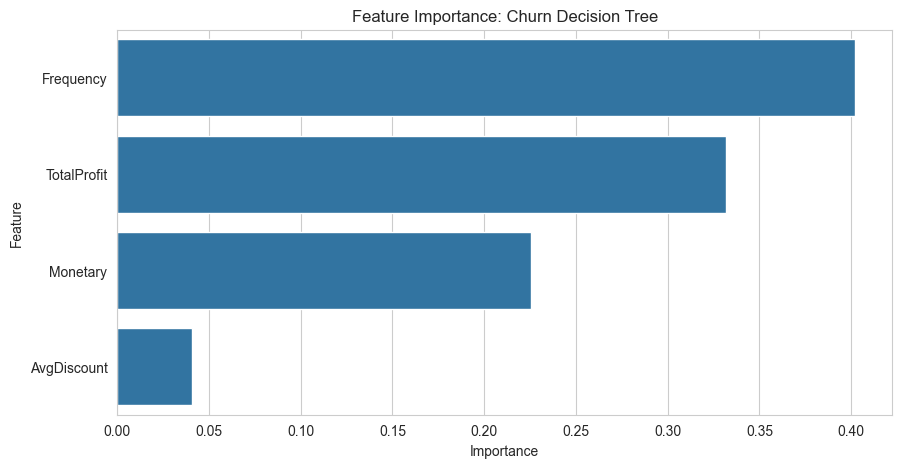

,Feature,Importance
0,Frequency,0.402186
3,TotalProfit,0.331674
1,Monetary,0.225585
2,AvgDiscount,0.040554


In [26]:
importance_df = pd.DataFrame({
    "Feature": X_clf.columns,
    "Importance": dt_clf.feature_importances_
}).sort_values("Importance", ascending=False)

sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance: Churn Decision Tree")
plt.show()
importance_df

**Observations:** Frequency is the strongest predictor (importance 0.40), followed by TotalProfit (0.33) and Monetary (0.23), while AvgDiscount contributes little (0.04). Customers who order less often and generate less profit are naturally more likely to have drifted away, while discount habits are a weaker churn signal.

### Model Limitations

- The churn label is a recency-based proxy, not a true churn event, so a flagged customer may simply be a low-frequency shopper rather than someone who has genuinely left.
- The dataset is moderately imbalanced (74.6 percent active vs 25.4 percent churned), and both models show low recall (0.12 to 0.22), meaning most true churners are currently missed.
- The Sales regression model explains only about 53 percent of variance and struggles specifically with high-value orders.
- Both predictive models use static, aggregated features and do not account for the seasonality identified in Section 2.
- Cluster sizes range from 55 to 247 customers, the smallest cluster should be interpreted with some caution despite being the most commercially interesting segment.